# Avaliação do Modelo de Classificação de Batatas

Este notebook carrega o modelo treinado (`modelo_batatas_finetuned.keras`), usa o conjunto de validação para gerar previsões e calcula as métricas de avaliação:

- Acurácia
- Precisão
- Recall (sensibilidade)
- F1-score
- Matriz de confusão

> Nota: o conjunto de validação é criado a partir da pasta `dataset/` com o mesmo split usado durante o treinamento.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# configurações de exibição de gráficos
%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Carregar modelo e dados de validação

Carregamos o modelo salvo em `modelo_batatas_finetuned.keras` e criamos o dataset de validação usando o mesmo split usado no treinamento.

In [13]:
MODEL_PATH = "modelo_batatas_finetuned.keras"

dataset_dir = "dataset"
image_size = (224, 224)
batch_size = 32
validation_split = 0.2
seed = 42

# Carregar o modelo
model = load_model(MODEL_PATH)

# Criar o dataset de validação (mesmos parâmetros usados no treinamento)
validation_dataset = image_dataset_from_directory(
    dataset_dir,
    validation_split=validation_split,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
)

class_names = validation_dataset.class_names
print("Classes detectadas:", class_names)
print("Número de lotes de validação:", len(validation_dataset))

Found 1146 files belonging to 2 classes.
Using 229 files for validation.
Classes detectadas: ['Doente', 'Saudavel']
Número de lotes de validação: 8


In [14]:
## 2.1 Avaliação de perda e acurácia no conjunto de validação

# Avaliar o modelo no conjunto de validação
loss, accuracy = model.evaluate(validation_dataset, verbose=1)

print(f"Loss (validação): {loss:.4f}")
print(f"Acurácia (validação): {accuracy:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 321ms/step - accuracy: 0.9389 - loss: 0.1445
Loss (validação): 0.1445
Acurácia (validação): 0.9389


## Gráfico de Loss e Acurácia por lote (batch)

Vamos calcular loss e acurácia para cada lote do conjunto de validação e plotar um gráfico 2D para visualizar a variação.

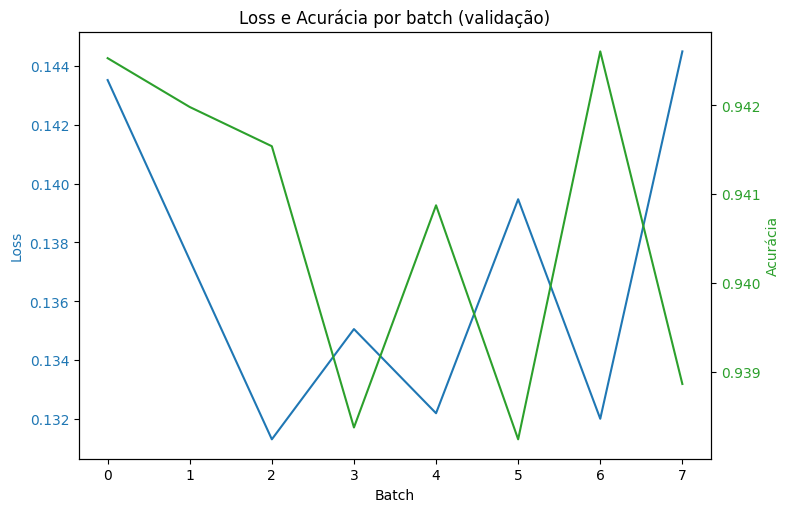

In [15]:
# Calcula loss e acurácia para cada lote no conjunto de validação
losses = []
accuracies = []
batch_idxs = []

for batch_idx, (images, labels) in enumerate(validation_dataset):
    batch_loss, batch_acc = model.test_on_batch(images, labels)
    losses.append(batch_loss)
    accuracies.append(batch_acc)
    batch_idxs.append(batch_idx)

# Exibir gráfico de loss e acurácia
fig, ax1 = plt.subplots()

color = "tab:blue"
ax1.set_xlabel("Batch")
ax1.set_ylabel("Loss", color=color)
ax1.plot(batch_idxs, losses, color=color, label="Loss")
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:green"
ax2.set_ylabel("Acurácia", color=color)
ax2.plot(batch_idxs, accuracies, color=color, label="Acurácia")
ax2.tick_params(axis="y", labelcolor=color)

fig.tight_layout()
plt.title("Loss e Acurácia por batch (validação)")
plt.show()

## 3. Gerar previsões

A seguir, percorremos o dataset de validação para obter os rótulos verdadeiros (`y_true`) e as previsões do modelo (`y_pred`).

In [16]:
y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images, verbose=0)
    preds_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy().tolist())
    y_pred.extend(preds_labels.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Total de amostras de validação: {len(y_true)}")

Total de amostras de validação: 229


## 4. Calcular métricas de avaliação

Usamos as funções do `sklearn.metrics` para calcular as métricas desejadas.

In [17]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="binary")
rec = recall_score(y_true, y_pred, average="binary")
f1 = f1_score(y_true, y_pred, average="binary")

print(f"Acurácia: {acc:.4f}")
print(f"Precisão: {prec:.4f}")
print(f"Recall (sensibilidade): {rec:.4f}")
print(f"F1-score: {f1:.4f}\n")

print("Relatório de classificação (por classe):")
print(classification_report(y_true, y_pred, target_names=class_names))

Acurácia: 0.9389
Precisão: 0.9143
Recall (sensibilidade): 0.9846
F1-score: 0.9481

Relatório de classificação (por classe):
              precision    recall  f1-score   support

      Doente       0.98      0.88      0.93        99
    Saudavel       0.91      0.98      0.95       130

    accuracy                           0.94       229
   macro avg       0.95      0.93      0.94       229
weighted avg       0.94      0.94      0.94       229



## 5. Exibir matriz de confusão

A matriz de confusão mostra quantas amostras foram classificadas corretamente ou incorretamente em cada classe.

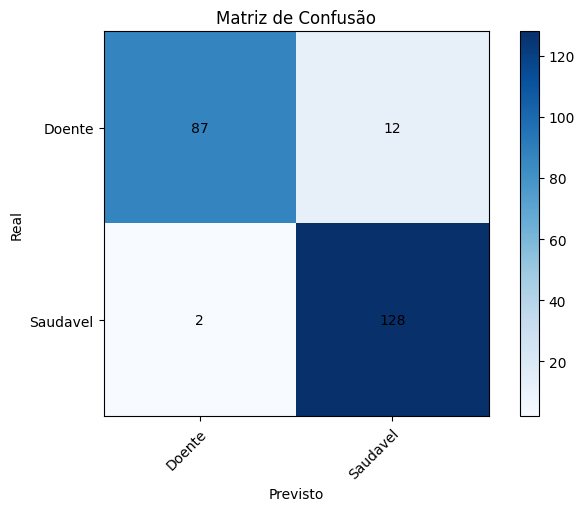

In [18]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots()

im = ax.imshow(cm, cmap="Blues")

# Labels
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

# Rotacionar os rótulos do eixo x para melhor visualização
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Loop sobre as dimensões dos dados e criar anotações de texto.
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão")
fig.colorbar(im, ax=ax)
plt.show()